In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("superstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df['Postal Code'].fillna(0, inplace=True)

C:\Users\Aadi\AppData\Local\Temp\ipykernel_26592\1688158443.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna(0, inplace=True)


In [6]:
df['Postal Code'] = df['Postal Code'].astype(int)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9800 non-null   int64  
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
if df.duplicated().sum() > 0:
    print("Duplicates Exist")
else:
    print("No duplicates found")

No duplicates found


In [9]:
customer_types = df['Segment'].unique()
print(f"Types of Customers : {customer_types}")

Types of Customers : ['Consumer' 'Corporate' 'Home Office']


In [10]:
number_of_customers = df['Segment'].value_counts().reset_index()
number_of_customers = number_of_customers.rename(columns = {'Segment':'Customer Type'})
print(f"{number_of_customers}")

  Customer Type  count
0      Consumer   5101
1     Corporate   2953
2   Home Office   1746


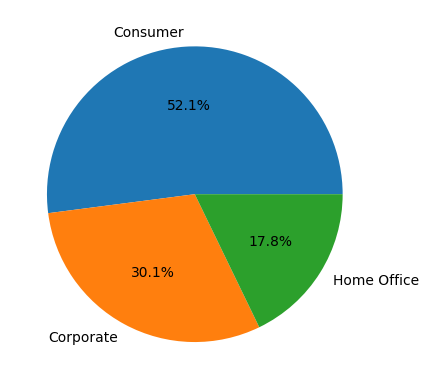

In [11]:
plt.pie(x = 'count', data = number_of_customers, labels='Customer Type', autopct="%1.1f%%")
plt.show()

In [12]:
sales_per_segment = df.groupby('Segment')['Sales'].sum().reset_index()
sales_per_segment = sales_per_segment.rename(columns={'Segment':'Customer Type', 'Sales':'Total Sales'})
print(sales_per_segment)

  Customer Type   Total Sales
0      Consumer  1.148061e+06
1     Corporate  6.884941e+05
2   Home Office  4.249822e+05


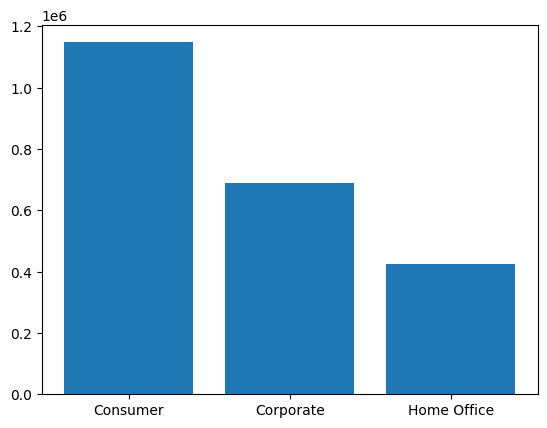

In [13]:
plt.bar(x='Customer Type', height='Total Sales', data = sales_per_segment)
plt.show()

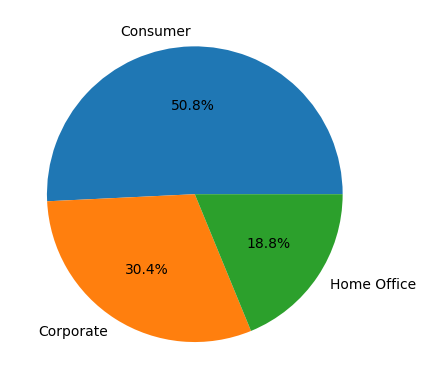

In [14]:
plt.pie(x='Total Sales', data = sales_per_segment, labels='Customer Type', autopct='%1.1f%%')
plt.show()

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [16]:
customer_order_frequency = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Order ID'].count().reset_index()
customer_order_frequency = customer_order_frequency.rename(columns={'Segment':'Customer Type','Order ID':'Orders'})
print(customer_order_frequency)

    Customer ID       Customer Name Customer Type  Orders
0      AA-10315          Alex Avila      Consumer      11
1      AA-10375        Allen Armold      Consumer      15
2      AA-10480        Andrew Allen      Consumer      12
3      AA-10645       Anna Andreadi      Consumer      18
4      AB-10015       Aaron Bergman      Consumer       6
..          ...                 ...           ...     ...
788    XP-21865        Xylona Preis      Consumer      28
789    YC-21895      Yoseph Carroll     Corporate       8
790    YS-21880       Yana Sorensen     Corporate      12
791    ZC-21910    Zuschuss Carroll      Consumer      31
792    ZD-21925  Zuschuss Donatelli      Consumer       9

[793 rows x 4 columns]


In [17]:
repeat_customers = customer_order_frequency[customer_order_frequency['Orders']>=1]
print(repeat_customers)

    Customer ID       Customer Name Customer Type  Orders
0      AA-10315          Alex Avila      Consumer      11
1      AA-10375        Allen Armold      Consumer      15
2      AA-10480        Andrew Allen      Consumer      12
3      AA-10645       Anna Andreadi      Consumer      18
4      AB-10015       Aaron Bergman      Consumer       6
..          ...                 ...           ...     ...
788    XP-21865        Xylona Preis      Consumer      28
789    YC-21895      Yoseph Carroll     Corporate       8
790    YS-21880       Yana Sorensen     Corporate      12
791    ZC-21910    Zuschuss Carroll      Consumer      31
792    ZD-21925  Zuschuss Donatelli      Consumer       9

[793 rows x 4 columns]


In [18]:
repeat_customers_sorted = repeat_customers.sort_values(by='Orders', ascending=False)
print(repeat_customers_sorted.head(10).reset_index(drop=True))

  Customer ID        Customer Name Customer Type  Orders
0    WB-21850        William Brown      Consumer      35
1    PP-18955           Paul Prost   Home Office      34
2    MA-17560         Matt Abelman   Home Office      34
3    JL-15835             John Lee      Consumer      33
4    SV-20365          Seth Vernon      Consumer      32
5    JD-15895     Jonathan Doherty     Corporate      32
6    CK-12205  Chloris Kastensmidt      Consumer      32
7    AP-10915       Arthur Prichep      Consumer      31
8    ZC-21910     Zuschuss Carroll      Consumer      31
9    EP-13915           Emily Phan      Consumer      31


In [19]:
customer_sales = df.groupby(['Customer ID','Customer Name','Segment'])['Sales'].sum().reset_index()
customer_sales.rename(columns={'Segment':'Customer Type', 'Sales':'Total Sales'}, inplace=True)
print(customer_sales)

    Customer ID       Customer Name Customer Type  Total Sales
0      AA-10315          Alex Avila      Consumer     5563.560
1      AA-10375        Allen Armold      Consumer     1056.390
2      AA-10480        Andrew Allen      Consumer     1790.512
3      AA-10645       Anna Andreadi      Consumer     5086.935
4      AB-10015       Aaron Bergman      Consumer      886.156
..          ...                 ...           ...          ...
788    XP-21865        Xylona Preis      Consumer     2374.658
789    YC-21895      Yoseph Carroll     Corporate     5454.350
790    YS-21880       Yana Sorensen     Corporate     6720.444
791    ZC-21910    Zuschuss Carroll      Consumer     8025.707
792    ZD-21925  Zuschuss Donatelli      Consumer     1493.944

[793 rows x 4 columns]


In [20]:
customer_sales_sorted = customer_sales.sort_values(by='Total Sales', ascending=False)
print(customer_sales_sorted.head(10).reset_index(drop=True))

  Customer ID       Customer Name Customer Type  Total Sales
0    SM-20320         Sean Miller   Home Office    25043.050
1    TC-20980        Tamara Chand     Corporate    19052.218
2    RB-19360        Raymond Buch      Consumer    15117.339
3    TA-21385        Tom Ashbrook   Home Office    14595.620
4    AB-10105       Adrian Barton      Consumer    14473.571
5    KL-16645        Ken Lonsdale      Consumer    14175.229
6    SC-20095        Sanjit Chand      Consumer    14142.334
7    HL-15040        Hunter Lopez      Consumer    12873.298
8    SE-20110        Sanjit Engle      Consumer    12209.438
9    CC-12370  Christopher Conant      Consumer    12129.072


In [21]:
shipping_model = df['Ship Mode'].value_counts().reset_index()
print(shipping_model)

        Ship Mode  count
0  Standard Class   5859
1    Second Class   1902
2     First Class   1501
3        Same Day    538


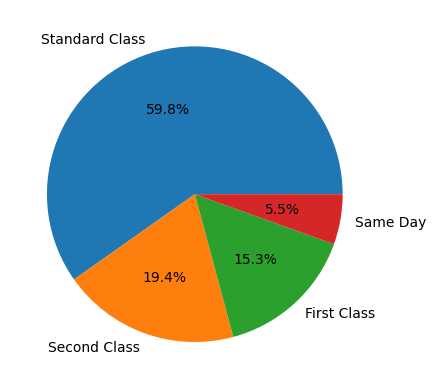

In [22]:
plt.pie(x='count', data=shipping_model, labels='Ship Mode', autopct="%1.1f%%",)
plt.show()

In [23]:
state = df['State'].value_counts().reset_index()
print(state.head(15))

             State  count
0       California   1946
1         New York   1097
2            Texas    973
3     Pennsylvania    582
4       Washington    504
5         Illinois    483
6             Ohio    454
7          Florida    373
8         Michigan    253
9   North Carolina    247
10        Virginia    224
11         Arizona    223
12       Tennessee    183
13        Colorado    179
14         Georgia    177


In [24]:
city = df['City'].value_counts().reset_index()
print(city.head(15))

             City  count
0   New York City    891
1     Los Angeles    728
2    Philadelphia    532
3   San Francisco    500
4         Seattle    426
5         Houston    374
6         Chicago    308
7        Columbus    221
8       San Diego    170
9     Springfield    161
10         Dallas    156
11   Jacksonville    125
12        Detroit    115
13         Newark     92
14        Jackson     82


In [25]:
sales_per_state = df.groupby('State')['Sales'].sum().reset_index()
sales_per_state_sorted = sales_per_state.sort_values(by='Sales', ascending=False)
print(sales_per_state_sorted.head(15).reset_index(drop=True))

             State        Sales
0       California  446306.4635
1         New York  306361.1470
2            Texas  168572.5322
3       Washington  135206.8500
4     Pennsylvania  116276.6500
5          Florida   88436.5320
6         Illinois   79236.5170
7         Michigan   76136.0740
8             Ohio   75130.3500
9         Virginia   70636.7200
10  North Carolina   55165.9640
11         Indiana   48718.4000
12         Georgia   48219.1100
13        Kentucky   36458.3900
14         Arizona   35272.6570


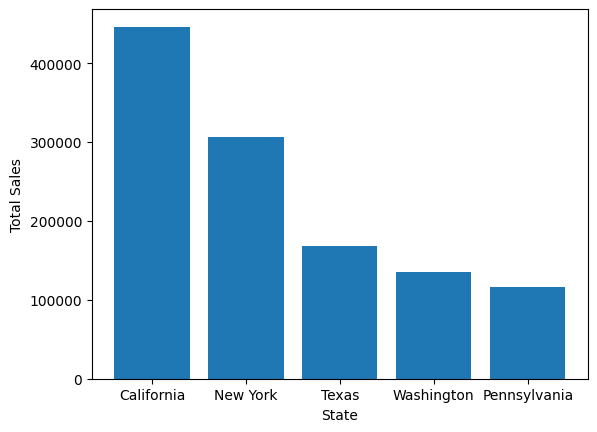

In [27]:
plt.bar(x='State', data=sales_per_state_sorted.head(5), height='Sales')
plt.ylabel("Total Sales")
plt.xlabel("State")
plt.show()

In [29]:
products = df['Category'].value_counts()
print(products)

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64


In [31]:
products_subcat = df['Sub-Category'].value_counts()
print(products_subcat)

Sub-Category
Binders        1492
Paper          1338
Furnishings     931
Phones          876
Storage         832
Art             785
Accessories     756
Chairs          607
Appliances      459
Labels          357
Tables          314
Envelopes       248
Bookcases       226
Fasteners       214
Supplies        184
Machines        115
Copiers          66
Name: count, dtype: int64


In [38]:
subcategory_count = df.groupby('Category')['Sub-Category'].nunique().reset_index()
print(subcategory_count)

          Category  Sub-Category
0        Furniture             4
1  Office Supplies             9
2       Technology             4


In [42]:
subcategory_count_sales = df.groupby(['Category','Sub-Category'])['Sales'].sum().reset_index()
print(subcategory_count_sales.sort_values(by='Sales', ascending=False).reset_index(drop=True))

           Category Sub-Category        Sales
0        Technology       Phones  327782.4480
1         Furniture       Chairs  322822.7310
2   Office Supplies      Storage  219343.3920
3         Furniture       Tables  202810.6280
4   Office Supplies      Binders  200028.7850
5        Technology     Machines  189238.6310
6        Technology  Accessories  164186.7000
7        Technology      Copiers  146248.0940
8         Furniture    Bookcases  113813.1987
9   Office Supplies   Appliances  104618.4030
10        Furniture  Furnishings   89212.0180
11  Office Supplies        Paper   76828.3040
12  Office Supplies     Supplies   46420.3080
13  Office Supplies          Art   26705.4100
14  Office Supplies    Envelopes   16128.0460
15  Office Supplies       Labels   12347.7260
16  Office Supplies    Fasteners    3001.9600


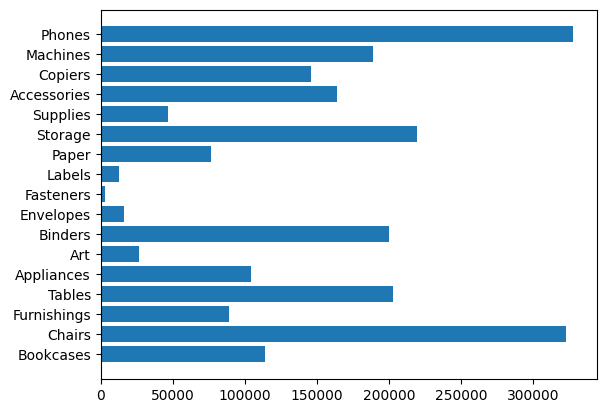

In [52]:
plt.barh(width='Sales', y='Sub-Category', data=subcategory_count_sales)
plt.show()

In [44]:
category_sales = df.groupby(['Category'])['Sales'].sum().reset_index()
print(category_sales.sort_values(by='Sales', ascending=False).reset_index(drop=True))

          Category        Sales
0       Technology  827455.8730
1        Furniture  728658.5757
2  Office Supplies  705422.3340


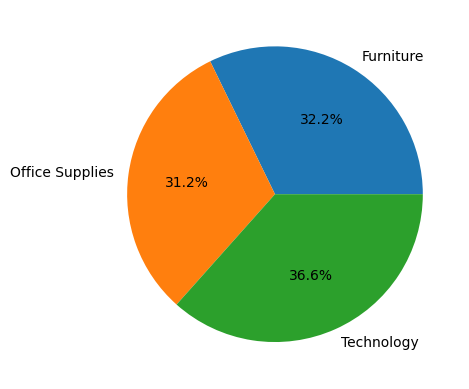

In [47]:
plt.pie(x='Sales', data=category_sales, labels='Category', autopct='%1.1f%%')
plt.show()

In [55]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [60]:
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum().reset_index()
yearly_sales.rename(columns={'Order Date':'Year'}, inplace=True)
print(yearly_sales)

   Year        Sales
0  2015  479856.2081
1  2016  459436.0054
2  2017  600192.5500
3  2018  722052.0192


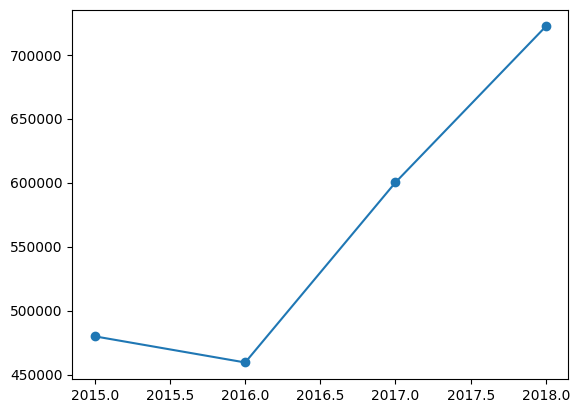

In [65]:
plt.plot(yearly_sales['Year'], yearly_sales['Sales'], marker='o')
plt.show()

In [73]:
yearly_sales_2018 = df[df['Order Date'].dt.year==2018]
monthly_sales = yearly_sales_2018.resample('ME', on='Order Date')['Sales'].sum().reset_index()
print(monthly_sales)

   Order Date        Sales
0  2018-01-31   43476.4740
1  2018-02-28   19920.9974
2  2018-03-31   58863.4128
3  2018-04-30   35541.9101
4  2018-05-31   43825.9822
5  2018-06-30   48190.7277
6  2018-07-31   44825.1040
7  2018-08-31   62837.8480
8  2018-09-30   86152.8880
9  2018-10-31   77448.1312
10 2018-11-30  117938.1550
11 2018-12-31   83030.3888


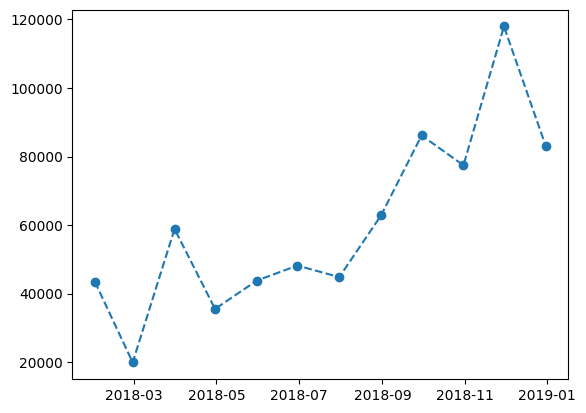

In [77]:
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], marker='o', linestyle='--')
plt.show()

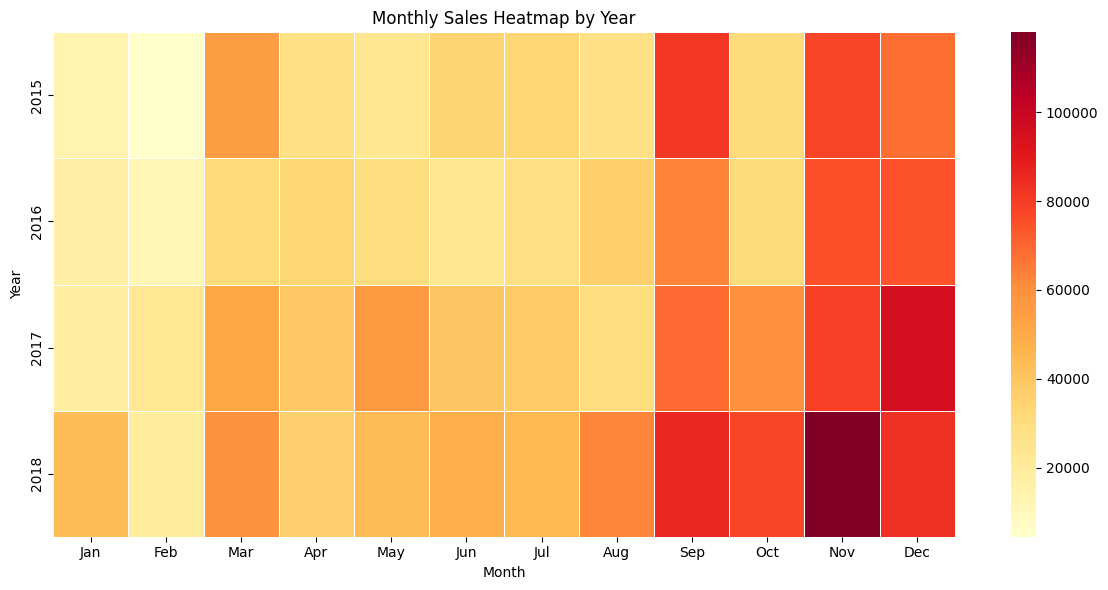

In [ ]:
import calendar
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Use the dataframe created earlier in the notebook.
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

us_state_abbrev = {
    'Alabama': 'AL', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 'Colorado': 'CO',
    'Connecticut': 'CT', 'Delaware': 'DE', 'District of Columbia': 'DC', 'Florida': 'FL',
    'Georgia': 'GA', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI',
    'Wyoming': 'WY'
}

sales_by_state = df.groupby('State', as_index=False)['Sales'].sum()
sales_by_state['State'] = sales_by_state['State'].map(us_state_abbrev)
sales_by_state = sales_by_state.dropna(subset=['State'])

fig = px.choropleth(
    sales_by_state,
    locations='State',
    locationmode='USA-states',
    color='Sales',
    scope='usa',
    color_continuous_scale='YlOrRd',
    title='Sales by State in the USA'
)
fig.show()

sales_by_time = df.copy()
sales_by_time['Year'] = sales_by_time['Order Date'].dt.year
sales_by_time['Month'] = sales_by_time['Order Date'].dt.month

sales_heatmap = sales_by_time.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
sales_heatmap = sales_heatmap.pivot(index='Year', columns='Month', values='Sales').sort_index(axis=1)
sales_heatmap.columns = [calendar.month_abbr[column] for column in sales_heatmap.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(sales_heatmap, cmap='YlOrRd', linewidths=0.5)
plt.title('Monthly Sales Heatmap by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()